In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation 
plt.rcParams.update({'font.size': 16})
import glob
import matplotlib.cm as cm

In [2]:
import torch
import numpy as np
import networkx as nx
import os

from floorplans.lidar.lidar import Lidar2D, OnlineTrajectoryLidarDataset

In [3]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 打印默认颜色数组
print(default_colors)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


In [4]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']


In [5]:
import math


def smooth(scalars, weight=0.9) :
    """
    EMA implementation according to
    https://github.com/tensorflow/tensorboard/blob/34877f15153e1a2087316b9952c931807a122aa7/tensorboard/components/vz_line_chart2/line-chart.ts#L699
    """
    last = 0
    smoothed = torch.zeros_like(scalars)
    num_acc = 0
    for next_val in scalars:
        last = last * weight + (1 - weight) * next_val
        num_acc += 1
        # de-bias
        debias_weight = 1
        if weight != 1:
            debias_weight = 1 - math.pow(weight, num_acc)
        smoothed_val = last / debias_weight
        smoothed[num_acc-1] = smoothed_val

    return smoothed

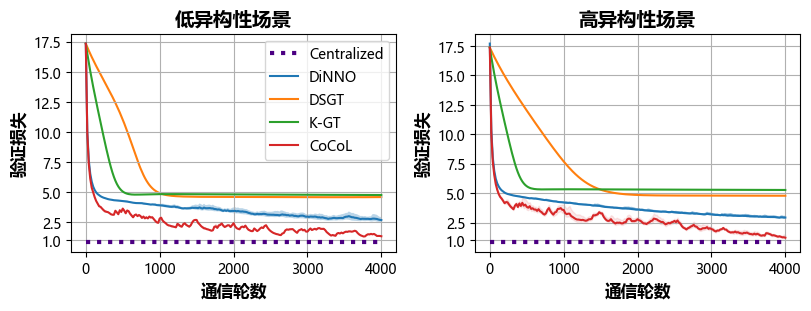

In [7]:
(fig, axs) = plt.subplots(nrows=1, ncols=2,figsize=(8,3),constrained_layout=True)
# plt.style.use('seaborn-v0_8-paper')  # 更改图表风格
model_param=25601*4/1024/1024 #MB
ax=axs[0]
results_dir0 = "../results/2024-05-13_07-02_dist_online_dense_PAPER"
results_dir= "../results/2024-04-08_08-53_dist_online_dense_PAPER"
results_sonata= "../results/2024-05-14_08-30_dist_online_dense_PAPER"
results_sonata="../results_paper/2024-09-05_21-15_dist_online_dense_sonata_iter"
# results_sonata= "../results_paper/2024-08-08_15-39_dist_online_dense_sonata_0.001"
# results_sonata="../results_paper/2024-08-08_14-39_dist_online_dense_sonata_check"
result_kgt="../results_paper/2024-08-05_18-24_dist_online_dense_kgt"
results1 = torch.load(os.path.join(results_dir, "dinno_log_results.pt"), map_location=torch.device("cpu"))
results2 = torch.load(os.path.join(results_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
results3 = torch.load(os.path.join(result_kgt, "kgt_results.pt"), map_location=torch.device("cpu"))

# results4= torch.load(os.path.join(results_sonata, "sonata_results.pt"), map_location=torch.device("cpu"))
results4= torch.load(os.path.join(results_sonata, "sonata_iter2_results.pt"), map_location=torch.device("cpu"))
# result_sonata="../results_iros/2025-02-14_15-20_dist_online_dense_repeat"
# results4= torch.load(os.path.join(result_sonata, "sonata_0_results.pt"), map_location=torch.device("cpu"))

results_solo = torch.load(os.path.join(results_dir, "solo_results.pt"), map_location=torch.device("cpu"))
vl1 = torch.stack(results1["validation_loss"])
vl2 = torch.stack(results2["validation_loss"])
vl3 = torch.stack(results3["validation_loss"])
vl4 = torch.stack(results4["validation_loss"])


t = np.arange(vl2.shape[0]) * 20
# t=cum_sum*20
t_dinno=torch.arange(vl1.shape[0]) * 20
# t_dinno=cum_sum*20
# data_transfer=t*model_param

# data_transfer_dinno=t_dinno*model_param


centralized_vloss = 0.89
ax.plot(t, centralized_vloss * np.ones_like(t), color="indigo",
    linestyle=":", linewidth=3, label="Centralized")
cadmm_mean = torch.mean(vl1, dim=1)
cadmm_min = torch.amin(vl1, dim=1)
cadmm_max = torch.amax(vl1, dim=1)
dsgt_mean = torch.mean(vl2, dim=1)
dsgt_min = torch.amin(vl2, dim=1)
dsgt_max = torch.amax(vl2, dim=1)
kgt_mean = torch.mean(vl3, dim=1)
kgt_min = torch.amin(vl3, dim=1)
kgt_max = torch.amax(vl3, dim=1)
sonata_mean= torch.mean(vl4,dim=1)
sonata_min = torch.amin(vl4, dim=1)
sonata_max = torch.amax(vl4, dim=1)

alpha = 0.75 # 平滑因子
cadmm_mean_smooth = smooth(cadmm_mean, alpha)
sonata_mean_smooth = smooth(sonata_mean, alpha)

ax.plot(t, cadmm_mean_smooth,  label="DiNNO",zorder=3)
ax.plot(t, dsgt_mean,  label="DSGT",zorder=1)
ax.plot(t, kgt_mean,  label="K-GT",zorder=2)
ax.plot(t, sonata_mean_smooth,  label="CoCoL",zorder=4)
ax.fill_between(t, smooth(cadmm_min,alpha), smooth(cadmm_max,alpha), alpha=0.3)
ax.fill_between(t, dsgt_min, dsgt_max,  alpha=0.5)
ax.fill_between(t, kgt_min, kgt_max,  alpha=0.5)
ax.fill_between(t, smooth(sonata_min,alpha), smooth(sonata_max,alpha),  alpha=0.5)
# ax.set_yscale("log")
ax.grid(zorder=0)
ax.legend(fontsize=10)
# ax.set_xlabel("Communication Rounds",fontsize=12)
# ax.set_ylabel("Validation Loss",fontsize=12)
# ax.set_title("Low-Heterogeneity",fontsize=14)
ax.set_xlabel("通信轮数",fontsize=12,fontweight='bold')
ax.set_ylabel("验证损失",fontsize=12,fontweight='bold')
ax.set_title("低异构性场景",fontsize=14,fontweight='bold')
ax.set_yticks([1.0,2.5,5.0,7.5,10.0,12.5,15.0,17.5])
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
results_dir_minimal = "../results/2024-07-30_19-18_dist_online_dense_minimal"
minimal_kgt_dir="../results_paper/2024-08-05_18-11_dist_online_dense_minimal_kgt"
dinno_dir_minimal="../results_iros/2025-02-11_21-38_dist_online_dense"
sonata_dir_minimal="../results/2024-07-30_19-18_dist_online_dense_minimal"
# sonata_dir_minimal="../results_iros/2025-02-11_22-06_dist_online_dense"
# min_results1 = torch.load(os.path.join(dinno_dir_minimal, "dinno_log_results.pt"), map_location=torch.device("cpu"))

# min_results1 = torch.load(os.path.join(dinno_dir_minimal, "dinno_results.pt"), map_location=torch.device("cpu"))

dinno_dir_minimal="../results_iros/2025-02-14_15-30_dist_online_dense_repeat_minimal_overlap"
sonata_dir_minimal=dinno_dir_minimal
min_results1= torch.load(os.path.join(dinno_dir_minimal, "dinno_2_results.pt"), map_location=torch.device("cpu"))
min_results2 = torch.load(os.path.join(results_dir_minimal, "sonata_results.pt"), map_location=torch.device("cpu"))
min_results3 = torch.load(os.path.join(minimal_kgt_dir, "kgt_results.pt"), map_location=torch.device("cpu"))
min_results4= torch.load(os.path.join(results_dir_minimal, "dsgt_results.pt"), map_location=torch.device("cpu"))


# results_solo = torch.load(os.path.join(results_dir2, "solo_results.pt"), map_location=torch.device("cpu"))

# min_dinno=torch.load(os.path.join(results_dir_minimal, "dinno_val_loss.pt"), map_location=torch.device("cpu"))
# min_vl1 = torch.stack(min_dinno)


min_vl1 = torch.stack(min_results1["validation_loss"])
min_vl2 = torch.stack(min_results2["validation_loss"])
min_vl3 = torch.stack(min_results3["validation_loss"])
min_vl4 = torch.stack(min_results4["validation_loss"])

# axs[1].clear()

t_dinno=torch.arange(min_vl1.shape[0]) * 20

data_transfer_dinno=t_dinno*model_param
#ind_color = "cornflowerblue"
#for i in results_solo.keys():
#    if i != 0:
#        ax.plot(t, results_solo[i]["validation_loss"] * np.ones_like(t),
#            color=ind_color, linestyle=":", linewidth=3)
#ax.plot(t, results_solo[0]["validation_loss"] * np.ones_like(t), 
#    color=ind_color, linestyle=":", label="Individual", linewidth=3)

centralized_vloss = 0.88
axs[1].plot(t, centralized_vloss * np.ones_like(t), color="indigo",
    linestyle=":",linewidth=3 , label="Centralized")

min_cadmm_mean = torch.mean(min_vl1, dim=1)
min_cadmm_min = torch.amin(min_vl1, dim=1)
min_cadmm_max = torch.amax(min_vl1, dim=1)
min_sonata_mean = torch.mean(min_vl2, dim=1)
min_sonata_min = torch.amin(min_vl2, dim=1)
min_sonata_max = torch.amax(min_vl2, dim=1)
min_kgt_mean = torch.mean(min_vl3, dim=1)
min_kgt_min = torch.amin(min_vl3, dim=1)
min_kgt_max = torch.amax(min_vl3, dim=1)
min_dsgt_mean= torch.mean(min_vl4,dim=1)
min_dsgt_min = torch.amin(min_vl4, dim=1)
min_dsgt_max = torch.amax(min_vl4, dim=1)

# 示例使用
alpha = 0.75  # 平滑因子
min_cadmm_mean_smooth = smooth(min_cadmm_mean, alpha)
min_sonata_mean_smooth = smooth(min_sonata_mean, alpha)

axs[1].plot(t, min_cadmm_mean_smooth,color=default_colors[0],  label="DiNNO")

axs[1].plot(t, min_dsgt_mean, color=default_colors[1],label="DSGT")
axs[1].plot(t, min_kgt_mean,color=default_colors[2],  label="K-GT")

axs[1].plot(t, min_sonata_mean_smooth,color=default_colors[3]   ,label="CoCoL")

# axs[1].text(-0.3,0.5,"Hard",horizontalalignment='center',verticalalignment='center',rotation=90,transform=axs[1].transAxes)


axs[1].fill_between(t, smooth(min_cadmm_min,alpha), smooth(min_cadmm_max,alpha), alpha=0.5)
axs[1].fill_between(t, min_dsgt_min, min_dsgt_max, alpha=0.5)
axs[1].fill_between(t, smooth(min_sonata_min,alpha), smooth(min_sonata_max,alpha), color=default_colors[3],alpha=0.1)
axs[1].fill_between(t, min_kgt_min, min_kgt_max,alpha=0.5)
# axs[1].set_yscale("log")
# axs[1].legend()
# axs[1].xaxis.set_major_locator(plt.MultipleLocator(1000))
axs[1].set_yticks([1.0,2.5,5.0,7.5,10.0,12.5,15.0,17.5])
axs[1].grid()
# axs[1].set_xlabel("Communication Rounds",fontsize=12)
# axs[1].set_ylabel("Validation Loss",fontsize=12)
# axs[1].set_title("High-Heterogeneity",fontsize=14)
axs[1].set_xlabel("通信轮数",fontsize=12,fontweight='bold')
axs[1].set_ylabel("验证损失",fontsize=12,fontweight='bold')
axs[1].set_title("高异构性场景",fontsize=14,fontweight='bold')
axs[1].tick_params(axis='x', labelsize=10)
axs[1].tick_params(axis='y', labelsize=10)

# fig.savefig("odense_vloss.svg")
# plt.show()
# fig

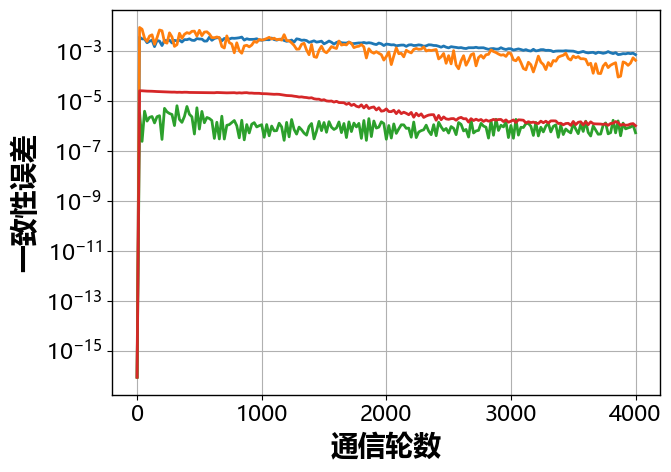

In [16]:
fig,ax=plt.subplots(1,1,figsize=(7,5), tight_layout=True)
ag_dinno = torch.vstack([v[1].reshape(1, -1) for v in min_results1["consensus_error"]])
ag_dsgt = torch.vstack([v[1].reshape(1, -1) for v in min_results2["consensus_error"]])
ag_kgt = torch.vstack([v[1].reshape(1, -1) for
    v in min_results3["consensus_error"]])
ag_cocol = torch.vstack([v[1].reshape(1, -1) for v in min_results4["consensus_error"]])
ax.plot(t,torch.mean(ag_dinno,dim=1), label='DINNO', linewidth=2)
ax.plot(t,torch.mean(ag_dsgt,dim=1), label='DSGT', linewidth=2)
ax.plot(t,torch.mean(ag_kgt,dim=1), label='K-GT', linewidth=2)
ax.plot(t,smooth(torch.mean(ag_cocol,dim=1),0), label='CoCoL', linewidth=2)
# ax.set_xlabel('Communication Rounds', fontsize=16)
# ax.set_ylabel('Consensus Error', fontsize=16)
ax.set_xlabel('通信轮数', fontsize=20,fontweight='bold')
ax.set_ylabel('一致性误差', fontsize=20,fontweight='bold')
ax.set_yscale('log')
ax.grid()
for spine in ax.spines.values():
    spine.set_linewidth(1)  # 你可以根据需要调整这个值
# ax.legend(loc='lower right',fontsize=13,shadow=True,frameon=True)
# fig.savefig("odense_consensus_low.pdf")


Text(0, 0.5, '高异构性场景')

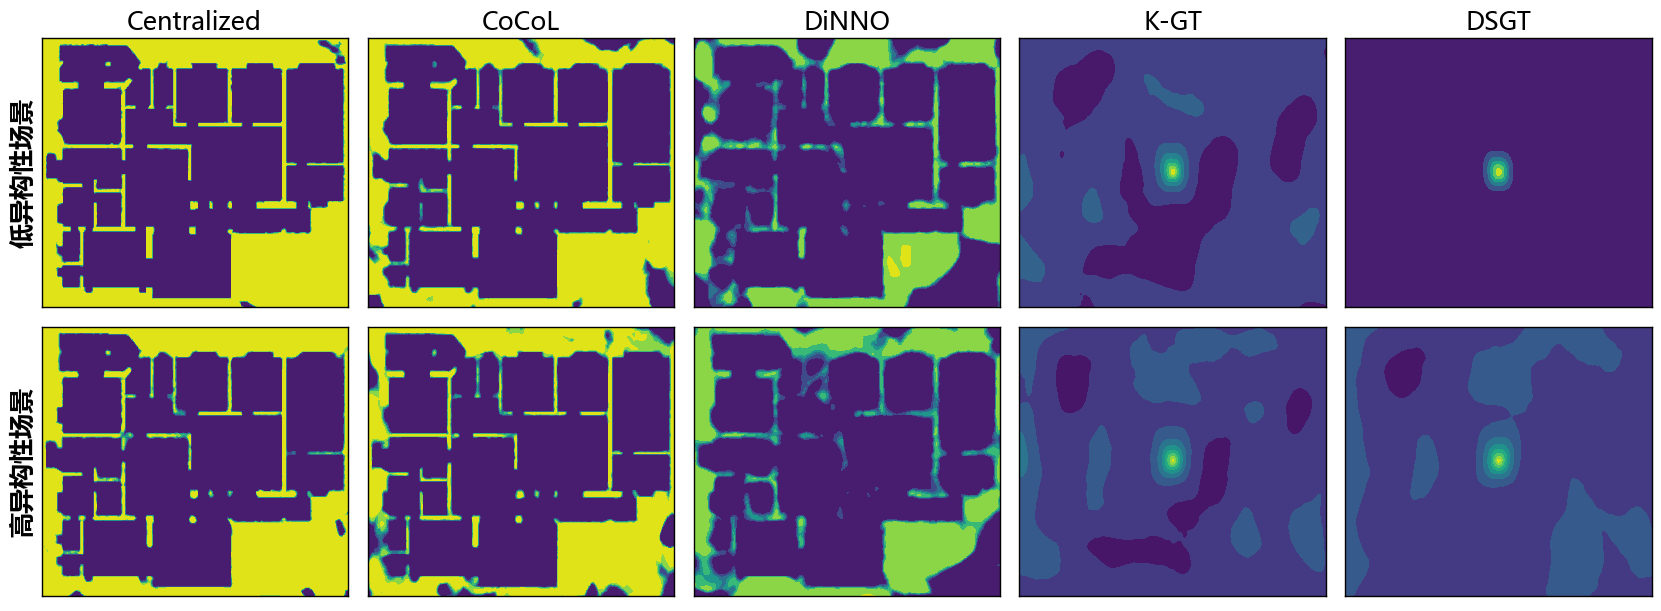

In [13]:
(fig,axs)= plt.subplots(nrows=2, ncols=5, figsize=(16.5, 6),constrained_layout=True)
locs = results1["mesh_inputs"]
min_cen_result=torch.load("../centralized/min_mesh/mesh_dense200.pt", map_location=torch.device("cpu"))
cen_result=torch.load("../centralized/mesh/mesh_dense200.pt", map_location=torch.device("cpu"))
levels=[0.,0.15,0.3,0.45,0.6,0.75,0.9,1.0]
# levels=[0.,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
font_size=18
from matplotlib.colors import Normalize
norm = Normalize(vmin=0, vmax=1.0)
axs[0,0].set_title("Centralized",fontsize=font_size)
# contour=axs[0,0].tricontourf(locs[:, 0], locs[:, 1], cen_result.squeeze())
contour=axs[0,0].tricontourf(locs[:, 0], locs[:, 1], cen_result.squeeze(),levels=levels)
# fig.colorbar(contour, ax=axs[0,4], shrink=0.5, aspect=5)
axs[1,0].tricontourf(locs[:, 0], locs[:, 1], min_cen_result.squeeze(),levels=levels)


sonata_den=results4["mesh_grid_density"]
sonata_pred1 = (torch.squeeze(sonata_den[-1]))[0, :]
min_sonata_den=min_results2["mesh_grid_density"]
sonata_pred2 = (torch.squeeze(min_sonata_den[-1]))[0 ,:]
axs[0,1].set_title("CoCoL",fontsize=font_size)
axs[0,1].tricontourf(locs[:, 0], locs[:, 1], sonata_pred1,levels=levels)
axs[1,1].tricontourf(locs[:, 0], locs[:, 1], sonata_pred2,levels=levels)

axs[0,2].set_title("DiNNO",fontsize=font_size)
dinno_den=results1["mesh_grid_density"]
dinno_pred1 = (torch.squeeze(dinno_den[-1]))[0, :]
min_dinno_den=min_results1["mesh_grid_density"]
dinno_pred2 = (torch.squeeze(min_dinno_den[-1]))[0 ,:]

# min_dinno_den=torch.load(os.path.join(results_dir_minimal, "dinno_min_den.pt"), map_location=torch.device("cpu"))
# dinno_pred2 = (torch.squeeze(min_dinno_den))[0 ,:]

axs[0,2].tricontourf(locs[:, 0], locs[:, 1], dinno_pred1,levels=levels)
axs[1,2].tricontourf(locs[:, 0], locs[:, 1], dinno_pred2,levels=levels)

axs[0,3].set_title("K-GT",fontsize=font_size)
kgt_den=results3["mesh_grid_density"]
kgt_pred1 = (torch.squeeze(kgt_den[-1]))[0, :]
min_kgt_den=min_results3["mesh_grid_density"]
kgt_pred2 = (torch.squeeze(min_kgt_den[-1]))[0 ,:]
axs[0,3].tricontourf(locs[:, 0], locs[:, 1], kgt_pred1)
axs[1,3].tricontourf(locs[:, 0], locs[:, 1], kgt_pred2)

axs[0,4].set_title("DSGT",fontsize=font_size)
dsgt_den=results2["mesh_grid_density"]
dsgt_pred1 = (torch.squeeze(dsgt_den[-1]))[0, :]
min_dsgt_den=min_results4["mesh_grid_density"]
dsgt_pred2 = (torch.squeeze(min_dsgt_den[-1]))[0 ,:]
axs[0,4].tricontourf(locs[:, 0], locs[:, 1], dsgt_pred1)
axs[1,4].tricontourf(locs[:, 0], locs[:, 1], dsgt_pred2)

for ax_row in axs[:,:]:
    for ax in ax_row:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
# axs[0,0].set_ylabel("Low-Heterogeneity",fontsize=font_size)
# axs[1,0].set_ylabel("High-Heterogeneity",fontsize=font_size)
axs[0,0].set_ylabel("低异构性场景",fontsize=font_size,fontweight='bold')
axs[1,0].set_ylabel("高异构性场景",fontsize=font_size,fontweight='bold')
# cbar.set_ticks([0, 0.5, 1])


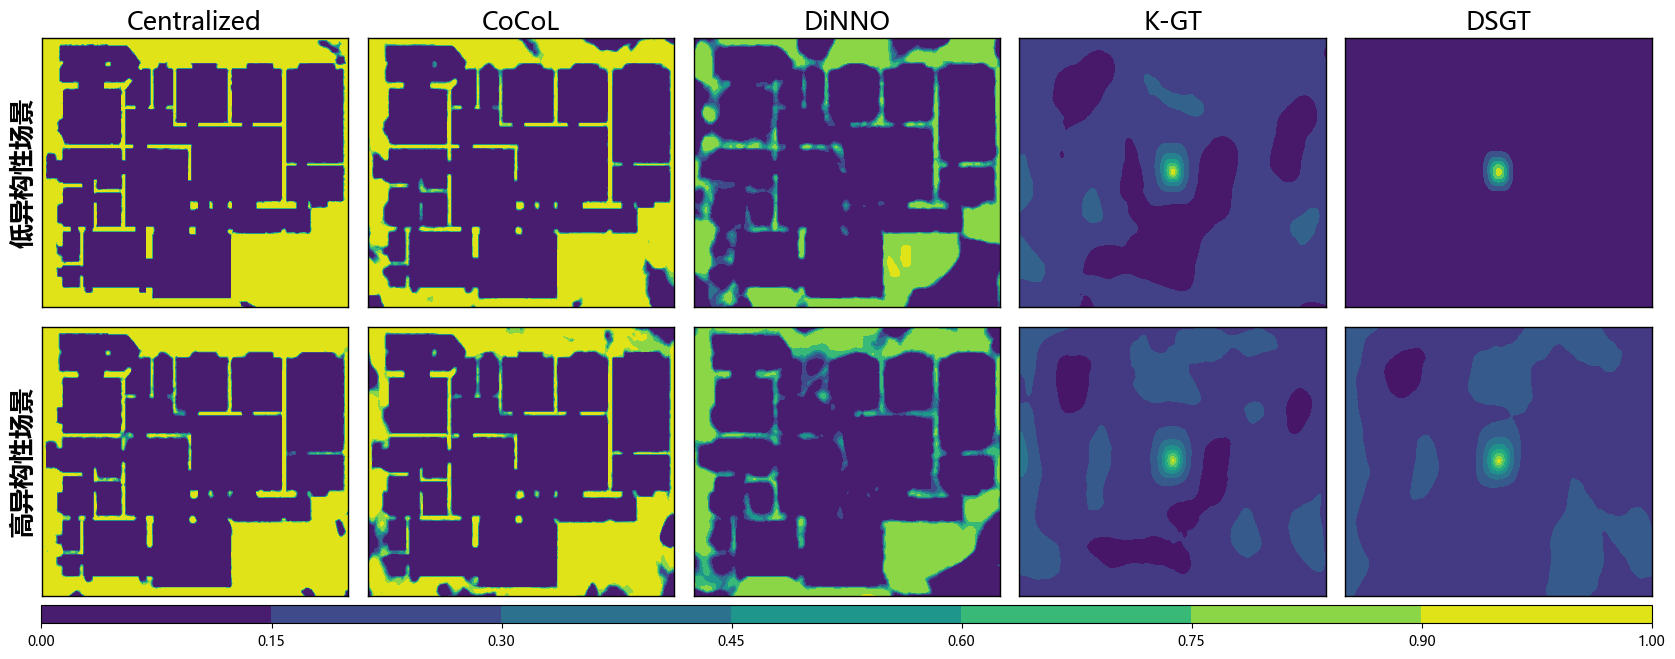

In [14]:
# cbar_ax.clear()
# cbar.remove()
position=axs[1,0].get_position()
position1=axs[1,4].get_position()
cbar_ax = fig.add_axes([position.x0, -0.03, position1.x0+position1.width-position.x0, 0.03])  # 调整这些值以适应你的图形布局

# 在新创建的轴上添加一个水平 colorbar
cbar=fig.colorbar(contour, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=10)
fig